In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from churn_prediction.paths import FEATURES_ONLINE_RETAIL_DIR, MODELS_ONLINE_RETAIL_DIR

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import joblib

## 1. Load & Merge Features + Labels

In [3]:
features = pd.read_parquet(FEATURES_ONLINE_RETAIL_DIR / 'features.parquet')
labels   = pd.read_parquet(FEATURES_ONLINE_RETAIL_DIR / 'labels.parquet')

# features được tính tại mỗi snapshot_date → cần join theo cả 2 key
# Nếu features chưa có snapshot_date, join theo Customer ID (fixed window)
if 'snapshot_date' in features.columns:
    df = labels.merge(features, on=['Customer ID', 'snapshot_date'], how='inner')
else:
    df = labels.merge(features, on='Customer ID', how='inner')

print(f"Merged shape : {df.shape}")
print(f"Churn rate   : {df['churn'].mean():.2%}")

Merged shape : (73439, 31)
Churn rate   : 58.64%


## 2. Chuẩn bị X, y, groups

In [4]:
DROP_COLS = ['Customer ID', 'snapshot_date', 'churn',
             'first_purchase_date', 'last_purchase_date']  # datetime không dùng trực tiếp

feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols]
y = df['churn']

# groups = Customer ID → dùng cho GroupKFold
# đảm bảo 1 khách không xuất hiện ở cả train lẫn val (data leakage)
groups = df['Customer ID'].values

print(f"Features : {X.shape[1]} cols")
print(f"Samples  : {X.shape[0]:,}")
print(f"\nClass distribution:")
print(y.value_counts().rename({0: 'retained', 1: 'churned'}))

Features : 26 cols
Samples  : 73,439

Class distribution:
churn
churned     43064
retained    30375
Name: count, dtype: int64


In [5]:
print(X.columns)

Index(['Recency', 'Frequency', 'Monetary', 'avg_order_value',
       'avg_items_per_order', 'total_quantity', 'total_orders',
       'unique_products_x', 'unique_purchase_days', 'avg_quantity_per_order',
       'max_order_value', 'min_order_value', 'customer_age_days',
       'days_since_last_purchase', 'purchase_span_days',
       'avg_days_between_orders', 'total_revenue', 'avg_revenue_per_item',
       'revenue_std', 'max_revenue', 'recent_30d_revenue', 'unique_products_y',
       'favorite_product_freq', 'repeat_product_ratio',
       'customer_lifetime_days', 'purchase_rate'],
      dtype='object')


## 3. Cross-validation với StratifiedGroupKFold

- **Stratified**: giữ tỷ lệ churn đều giữa các fold
- **Group**: 1 khách hàng chỉ xuất hiện ở train hoặc val, không cả hai → tránh data leakage

In [5]:
N_SPLITS = 5
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# scale_pos_weight cho imbalanced data (XGB/LGB)
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}  (neg={neg:,} / pos={pos:,})")

MODELS = {
    'LogisticRegression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     LogisticRegression(
                        class_weight='balanced',
                        max_iter=1000,
                        random_state=42
                    ))
    ]),

    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     RandomForestClassifier(
                        n_estimators=300,
                        class_weight='balanced',
                        max_depth=10,
                        random_state=42,
                        n_jobs=-1
                    ))
    ]),

    'XGBoost': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     XGBClassifier(
                        n_estimators=300,
                        max_depth=6,
                        learning_rate=0.05,
                        scale_pos_weight=scale_pos_weight,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        eval_metric='auc',
                        random_state=42,
                        n_jobs=-1
                    ))
    ]),

    'LightGBM': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     LGBMClassifier(
                        n_estimators=300,
                        max_depth=6,
                        learning_rate=0.05,
                        scale_pos_weight=scale_pos_weight,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        random_state=42,
                        n_jobs=-1,
                        verbose=-1
                    ))
    ]),
}

scale_pos_weight: 0.71  (neg=30,375 / pos=43,064)


In [6]:
results = {}

for name, pipeline in MODELS.items():
    fold_metrics = {'auc': [], 'f1': [], 'precision': [], 'recall': []}

    for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(X, y, groups=groups)
    ):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)
        y_prob = pipeline.predict_proba(X_val)[:, 1]
        y_pred = pipeline.predict(X_val)

        fold_metrics['auc'].append(roc_auc_score(y_val, y_prob))
        fold_metrics['f1'].append(f1_score(y_val, y_pred))
        fold_metrics['precision'].append(precision_score(y_val, y_pred))
        fold_metrics['recall'].append(recall_score(y_val, y_pred))

    results[name] = {k: np.mean(v) for k, v in fold_metrics.items()}
    results[name]['auc_std'] = np.std(fold_metrics['auc'])
    print(f"✓ {name}  AUC={results[name]['auc']:.4f} ± {results[name]['auc_std']:.4f}")

results_df = pd.DataFrame(results).T.sort_values('auc', ascending=False)
print("\n── Kết quả tổng hợp ──")
print(results_df.round(4).to_string())

✓ LogisticRegression  AUC=0.8780 ± 0.0025
✓ RandomForest  AUC=0.8925 ± 0.0046
✓ XGBoost  AUC=0.8930 ± 0.0044
✓ LightGBM  AUC=0.8928 ± 0.0045

── Kết quả tổng hợp ──
                       auc      f1  precision  recall  auc_std
XGBoost             0.8930  0.8216     0.8590  0.7874   0.0044
LightGBM            0.8928  0.8214     0.8581  0.7878   0.0045
RandomForest        0.8925  0.8219     0.8571  0.7895   0.0046
LogisticRegression  0.8780  0.8160     0.8443  0.7895   0.0025


## 4. Train model tốt nhất trên toàn bộ data + SHAP

Best model: XGBoost


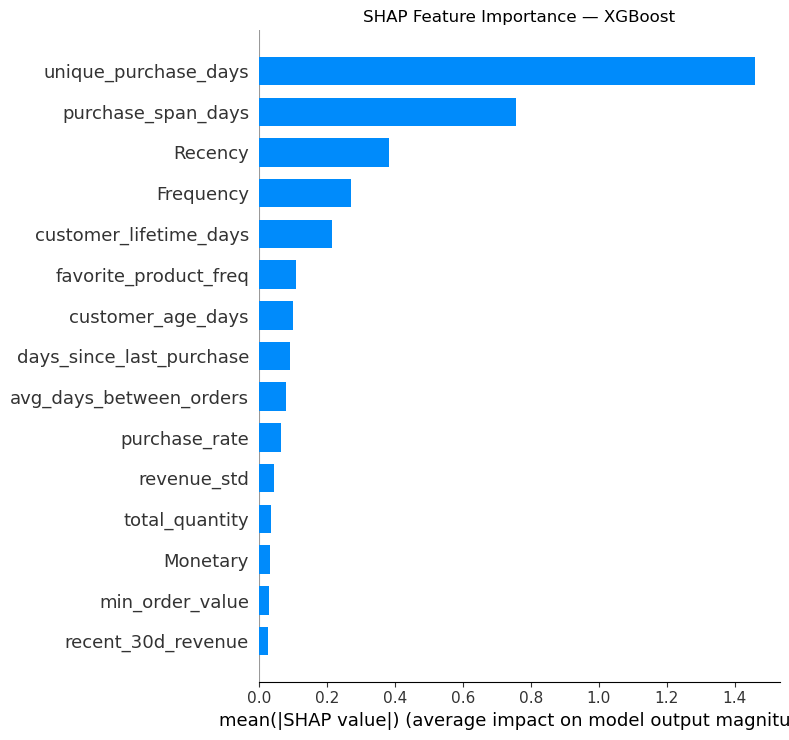

Saved shap_importance.png


In [13]:
best_name = results_df.index[0]
best_pipeline = MODELS[best_name]
print(f"Best model: {best_name}")

best_pipeline.fit(X, y)

# Lấy classifier và dữ liệu đã impute để tính SHAP
X_imputed = pd.DataFrame(
    best_pipeline.named_steps['imputer'].transform(X),
    columns=feature_cols
)

clf = best_pipeline.named_steps['clf']

if best_name == 'LogisticRegression':
    X_scaled = pd.DataFrame(
        best_pipeline.named_steps['scaler'].transform(X_imputed),
        columns=feature_cols
    )
    explainer = shap.LinearExplainer(clf, X_scaled)
    shap_values = explainer.shap_values(X_scaled)
    shap_data = X_scaled
else:
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_imputed)
    shap_data = X_imputed
    # LightGBM trả về list [class0, class1]
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

# SHAP summary plot
plt.figure()
shap.summary_plot(shap_values, shap_data, plot_type='bar',
                  max_display=15, show=False)
plt.title(f'SHAP Feature Importance — {best_name}')
plt.tight_layout()
plt.savefig(MODELS_ONLINE_RETAIL_DIR / 'shap_importance.png', dpi=150)
plt.show()
print("Saved shap_importance.png")

## 5. Đánh giá chi tiết trên fold cuối

── XGBoost — Classification Report ──
              precision    recall  f1-score   support

    retained       0.74      0.82      0.78      5981
     churned       0.87      0.80      0.83      8658

    accuracy                           0.81     14639
   macro avg       0.80      0.81      0.80     14639
weighted avg       0.81      0.81      0.81     14639



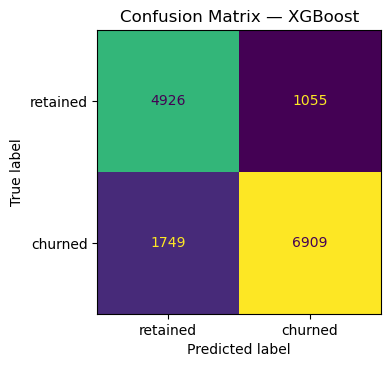

In [14]:
# Dùng fold cuối của best model để xem classification report
splits = list(sgkf.split(X, y, groups=groups))
train_idx, val_idx = splits[-1]

best_pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
y_pred = best_pipeline.predict(X.iloc[val_idx])
y_prob = best_pipeline.predict_proba(X.iloc[val_idx])[:, 1]

print(f"── {best_name} — Classification Report ──")
print(classification_report(y.iloc[val_idx], y_pred,
                            target_names=['retained', 'churned']))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y.iloc[val_idx], y_pred,
    display_labels=['retained', 'churned'],
    ax=ax, colorbar=False
)
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

## 6. Lưu model & kết quả

In [15]:
# Retrain trên toàn bộ data trước khi lưu
best_pipeline.fit(X, y)
joblib.dump(best_pipeline, MODELS_ONLINE_RETAIL_DIR / 'churn_model.pkl')

results_df.to_csv(MODELS_ONLINE_RETAIL_DIR / 'model_comparison.csv')

print(f"Saved churn_model.pkl  ({best_name})")
print(f"Saved model_comparison.csv")
print(f"\n── Final leaderboard ──")
print(results_df[['auc','auc_std','f1','precision','recall']].round(4).to_string())

Saved churn_model.pkl  (XGBoost)
Saved model_comparison.csv

── Final leaderboard ──
                       auc  auc_std      f1  precision  recall
XGBoost             0.8930   0.0044  0.8216     0.8590  0.7874
LightGBM            0.8928   0.0045  0.8214     0.8581  0.7878
RandomForest        0.8925   0.0046  0.8219     0.8571  0.7895
LogisticRegression  0.8780   0.0025  0.8160     0.8443  0.7895
